# Phase 4/5 — Sales EDA

Revenue trend, product distribution, regional differences, seasonality (incl. formal hypothesis tests across the full UAE holiday/seasonal calendar — Ramadan, Eid, National Day, Summer, Back-to-school, Year-end), discount relationships, and customer segments.

**Prerequisite:** `make etl` has been run and `DATABASE_URL` points at the populated warehouse (see `etl/README.md`).

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.eda import data_access, stats_tests

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


In [2]:
from src.common.uae_calendar import SEASONAL_CATEGORIES, label_category

sales = data_access.load_sales_detail()
sales.shape

(293169, 21)

## 1. Revenue trend

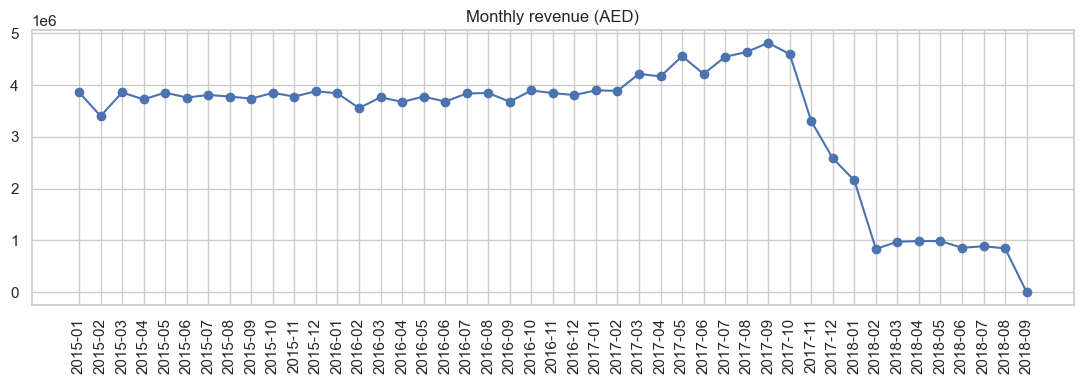

In [3]:
monthly = data_access.run_sql_file('02_sales/03_revenue_by_month.sql')
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly['period'], monthly['revenue_aed'], marker='o')
ax.set_title('Monthly revenue (AED)')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## 2. Product distribution

Line-item revenue is heavily right-skewed (a few big-ticket items, many cheap ones) — shown here on a log scale, which is standard for monetary distributions like this.

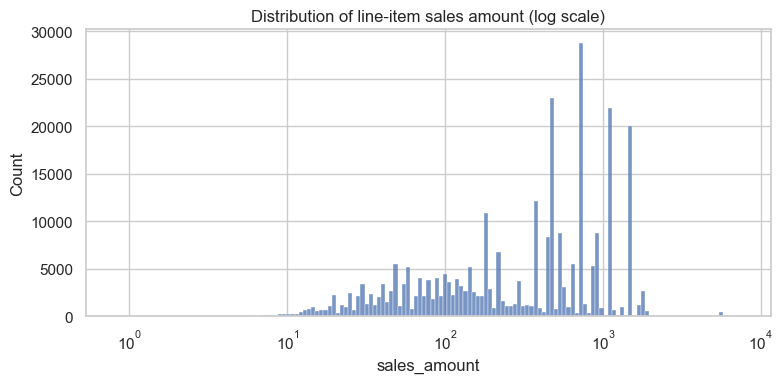

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(sales['sales_amount'].clip(lower=0.01), log_scale=True, ax=ax)
ax.set_title('Distribution of line-item sales amount (log scale)')
plt.tight_layout()
plt.show()

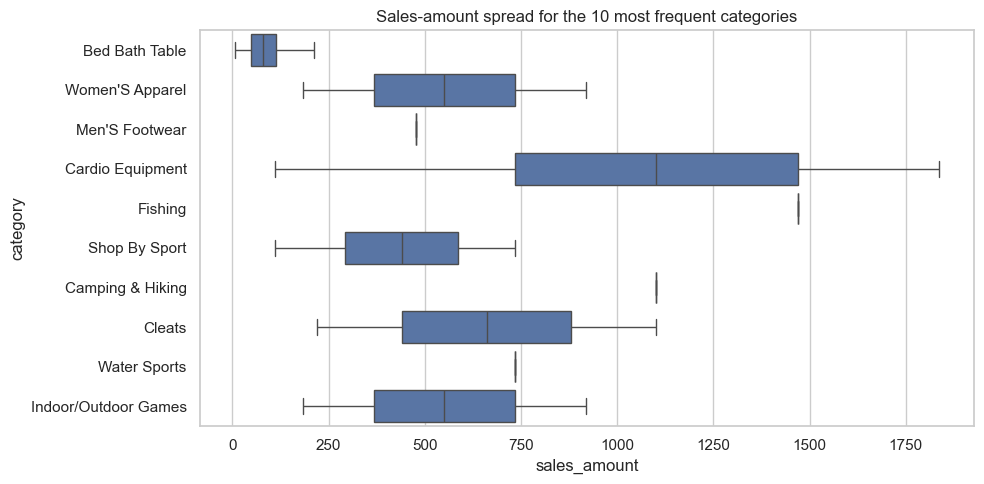

In [5]:
top_categories = sales['category'].value_counts().head(10).index
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=sales[sales['category'].isin(top_categories)],
    x='sales_amount', y='category', ax=ax, showfliers=False,
)
ax.set_title('Sales-amount spread for the 10 most frequent categories')
plt.tight_layout()
plt.show()

## 3. Regional differences

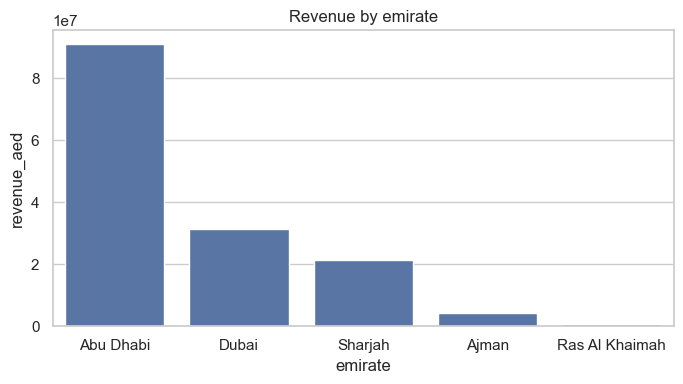

,emirate,order_count,revenue_aed
0,Abu Dhabi,112731,"90,916,633.42"
1,Dubai,33077,"31,329,311.90"
2,Sharjah,11959,"21,486,254.00"
3,Ajman,2806,"4,232,286.75"
4,Ras Al Khaimah,3845,"583,313.00"


In [6]:
by_region = data_access.run_sql_file('02_sales/01_revenue_by_region.sql')
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=by_region, x='emirate', y='revenue_aed', ax=ax)
ax.set_title('Revenue by emirate')
plt.tight_layout()
plt.show()
by_region

## 4. Seasonality

First, the plain month-of-year pattern (pooling all years), then formal tests across the full UAE holiday/seasonal calendar (`src/common/uae_calendar.py`, Phase 5). Two different kinds of "season" are tested, and neither is assumed to raise revenue going in (docs/business_requirements.md §7):

- **Real, published dates** — Ramadan, Eid al-Fitr/al-Adha, National Day.
- **Stated, disclosed windows** — Summer, Back-to-school, Year-end (e.g. "Summer = June 1 - September 15"), not discovered from the data.

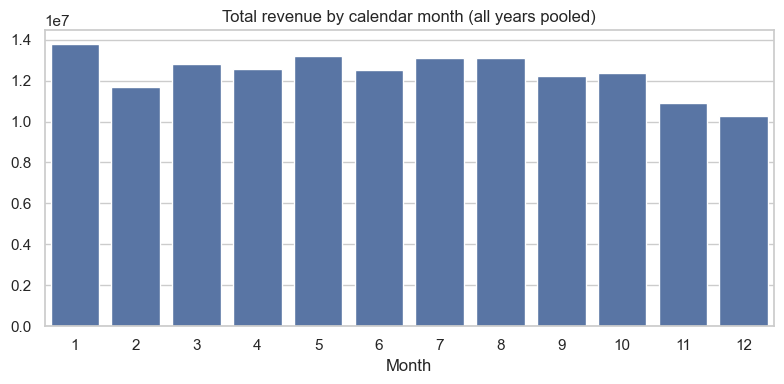

In [7]:
month_of_year = sales.groupby('month')['sales_amount'].sum()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=month_of_year.index, y=month_of_year.values, ax=ax)
ax.set_title('Total revenue by calendar month (all years pooled)')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

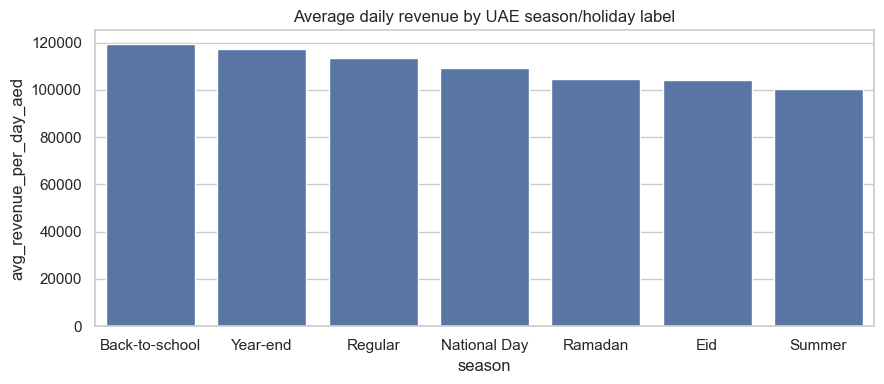

,season,days_in_period,revenue_aed,avg_revenue_per_day_aed
0,Back-to-school,103,"12,276,897.21","119,193.18"
1,Year-end,51,"5,974,168.38","117,140.56"
2,Regular,842,"95,368,290.48","113,264.00"
3,National Day,9,"983,508.52","109,278.72"
4,Ramadan,118,"12,315,332.05","104,367.22"
5,Eid,24,"2,503,242.38","104,301.77"
6,Summer,191,"19,126,360.05","100,138.01"


In [8]:
by_uae_season = data_access.run_sql_file('02_sales/07_revenue_by_uae_season.sql')
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=by_uae_season, x='season', y='avg_revenue_per_day_aed', ax=ax)
ax.set_title('Average daily revenue by UAE season/holiday label')
plt.tight_layout()
plt.show()
by_uae_season

### Hypothesis tests — each UAE seasonal/holiday category vs. the rest of the year

Demand is measured as **total daily revenue** (not line-item revenue — the unit of comparison is "a day", so line items must be aggregated to daily totals first, or every day would be represented by dozens of correlated line-item observations instead of one). Each category is tested independently against every other day (not against each other), since the categories aren't mutually exclusive in the underlying predicates even though `season_label` picks one winner per day.

In [9]:
daily = sales.groupby('order_date')['sales_amount'].sum().reset_index()

seasonal_rows = []
for category in SEASONAL_CATEGORIES:
    labels = label_category(daily['order_date'], category)
    in_group = daily.loc[labels == category, 'sales_amount'].to_numpy()
    out_group = daily.loc[labels == f'Non-{category}', 'sales_amount'].to_numpy()
    if len(in_group) < 3 or len(out_group) < 3:
        continue
    result = stats_tests.compare_two_groups(
        in_group, out_group,
        question=f'Does daily demand differ during {category}?',
        h0=f'Mean/median daily revenue is the same during {category} as outside it.',
        h1=f'Mean/median daily revenue during {category} differs from outside it.',
    )
    seasonal_rows.append({
        'category': category,
        'n_days': len(in_group),
        'test_used': result.test_used,
        'p_value': result.p_value,
        'effect_size': result.effect_size,
        'significant': result.reject_null,
        'direction': 'higher' if in_group.mean() > out_group.mean() else 'lower',
    })
    print(result.summary())
    print()

seasonal_summary = pd.DataFrame(seasonal_rows)
seasonal_summary

Q: Does daily demand differ during National Day?
H0: Mean/median daily revenue is the same during National Day as outside it.
H1: Mean/median daily revenue during National Day differs from outside it.
Test: Mann-Whitney U | statistic=5057.0000 | p=0.4243 | rank-biserial r=0.1544
Result: fail to reject H0 at alpha=0.05 — group A's mean/median is lower than group B's, a not statistically significant difference (|rank-biserial r|=0.154).

Q: Does daily demand differ during Eid?
H0: Mean/median daily revenue is the same during Eid as outside it.
H1: Mean/median daily revenue during Eid differs from outside it.
Test: Mann-Whitney U | statistic=15175.0000 | p=0.7521 | rank-biserial r=0.0376
Result: fail to reject H0 at alpha=0.05 — group A's mean/median is lower than group B's, a not statistically significant difference (|rank-biserial r|=0.038).

Q: Does daily demand differ during Ramadan?
H0: Mean/median daily revenue is the same during Ramadan as outside it.
H1: Mean/median daily revenue 

,category,n_days,test_used,p_value,effect_size,significant,direction
0,National Day,9,Mann-Whitney U,0.42,0.15,False,lower
1,Eid,24,Mann-Whitney U,0.75,0.04,False,lower
2,Ramadan,118,Mann-Whitney U,0.49,0.04,False,lower
3,Back-to-school,112,Mann-Whitney U,0.01,-0.14,True,higher
4,Year-end,51,Mann-Whitney U,0.74,0.03,False,higher
5,Summer,412,Mann-Whitney U,0.52,-0.02,False,lower


Some of these will come back not statistically significant, and at least one 'significant' result may point **lower**, not higher — both are valid, reportable findings, not something to explain away.

## 5. Discount relationships

Only DataCo carries real discount data (`Order Item Discount`) — Olist has none, so `discount_amount_aed` is always 0 there and those rows are excluded from this section rather than diluting it with structural zeros.

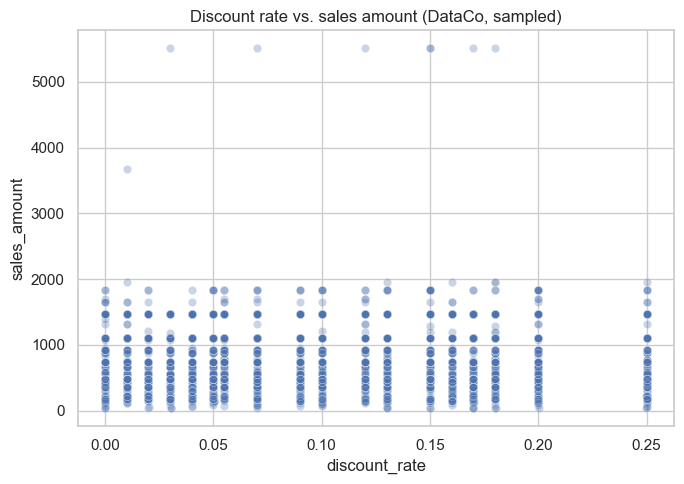

Spearman correlation (discount rate vs. sales amount): r=-0.015, p=1.378e-10


In [10]:
from scipy.stats import spearmanr

dataco_sales = sales[sales['source_system'] == 'dataco'].copy()
dataco_sales['discount_rate'] = dataco_sales['discount'] / (
    dataco_sales['unit_price'] * dataco_sales['quantity']
).replace(0, pd.NA)

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=dataco_sales.sample(min(3000, len(dataco_sales)), random_state=42),
    x='discount_rate', y='sales_amount', alpha=0.3, ax=ax,
)
ax.set_title('Discount rate vs. sales amount (DataCo, sampled)')
plt.tight_layout()
plt.show()

valid = dataco_sales.dropna(subset=['discount_rate'])
corr, p = spearmanr(valid['discount_rate'], valid['sales_amount'])
print(f'Spearman correlation (discount rate vs. sales amount): r={corr:.3f}, p={p:.4g}')

## 6. Customer segments

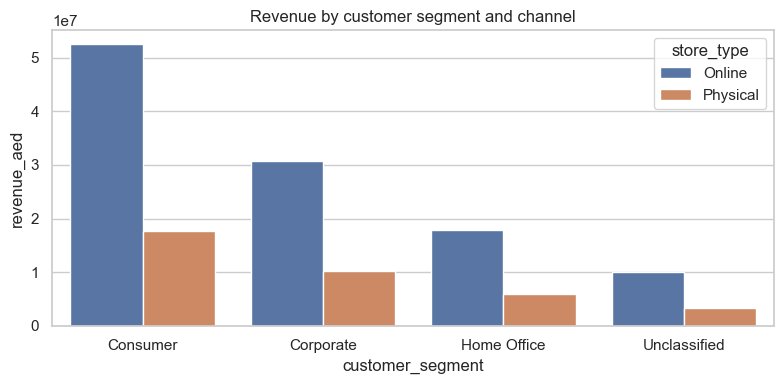

,customer_segment,store_type,customer_count,revenue_aed
0,Consumer,Online,9592,"52,456,999.85"
1,Corporate,Online,5616,"30,829,415.62"
2,Home Office,Online,3285,"17,930,040.87"
3,Consumer,Physical,7022,"17,672,372.51"
4,Corporate,Physical,4056,"10,186,606.71"
5,Unclassified,Online,76165,"10,112,846.69"
6,Home Office,Physical,2469,"6,016,663.23"
7,Unclassified,Physical,26706,"3,342,853.59"


In [11]:
by_segment = data_access.run_sql_file('06_customer/01_customer_segment_breakdown.sql')
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=by_segment, x='customer_segment', y='revenue_aed', hue='store_type', ax=ax)
ax.set_title('Revenue by customer segment and channel')
plt.tight_layout()
plt.show()
by_segment